# Validation Notebook — Teacher vs Student Models (PyTorch Lightning)

This notebook reproduces the **evaluation pipeline reported in Chapter 4** of the thesis.

Scope of this notebook:
- Load **pretrained teacher and student models** (no training)
- Use the **same PyTorch Lightning checkpoints** as in the thesis
- Generate property-conditioned SMILES
- Compute molecular properties using **RDKit**
- Compare **test vs generated distributions**
- Report **chemical validity** and **histograms** for selected properties

⚠️ No training or fine-tuning is performed in this notebook.


In [1]:

import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import pytorch_lightning as pl  
from sklearn.metrics.pairwise import rbf_kernel
from tqdm import tqdm


Project Path Setup

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx


Import ONLY official evaluation functions

In [3]:
from src.run_evaluation_prompt import (
    generate_conditioned,
    is_valid_smiles,
    build_targets_and_normalizers,
    clean_smiles,
    rdkit_properties_raw,
    PROPERTY_BASE_COLS
)


Device & Reproducibility

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)




Load Tokenizer (same as training)

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "hkqiu/PolyTAO-BigSMILES_Version"
)


Load Teacher Model (local checkpoint)

In [6]:
from transformers import AutoModelForSeq2SeqLM
import torch.nn as nn

TEACHER_DIR = PROJECT_ROOT / "checkpoints" / "teacher" / "model"

teacher = AutoModelForSeq2SeqLM.from_pretrained(
    TEACHER_DIR
).to(DEVICE).eval()

teacher_proj = nn.Linear(15, teacher.config.d_model).to(DEVICE)
teacher_proj.load_state_dict(
    torch.load(TEACHER_DIR / "property_proj.pt", map_location=DEVICE)
)
teacher_proj.eval()


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Linear(in_features=15, out_features=768, bias=True)

In [7]:
def load_Teacher():
    model_dir = (
        PROJECT_ROOT
        / "checkpoints"
        / "teacher"
        / "model"
    )

    model_path = model_dir.resolve().as_posix()
    print("model path:", model_path)

    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_path,
        local_files_only=True
    ).to(DEVICE).eval()

    proj = nn.Linear(15, model.config.d_model).to(DEVICE)
    proj.load_state_dict(
        torch.load(model_dir / "property_proj.pt", map_location=DEVICE)
    )
    proj.eval()

    return model, proj


Student Loader Function (generic)

In [8]:
def load_student(capacity):
    model_dir = (
        PROJECT_ROOT
        / "checkpoints"
        / "polytao_student_distilled"
        / f"student_{capacity}"
        / "model"
    )

    model_path = model_dir.resolve().as_posix()
    print("model path:", model_path)

    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_path,
        local_files_only=True
    ).to(DEVICE).eval()

    proj = nn.Linear(15, model.config.d_model).to(DEVICE)
    proj.load_state_dict(
        torch.load(model_dir / "property_proj_student.pt", map_location=DEVICE)
    )
    proj.eval()

    return model, proj


Load Test Set (fixed, no leakage)

In [9]:
TEST_CSV = PROJECT_ROOT / "data" / "polymers_with_properties_normalized_test.csv"
df_test = pd.read_csv(TEST_CSV)

Train_CSV = PROJECT_ROOT / "data" / "polymers_with_properties_normalized_train.csv"
df_train = pd.read_csv(Train_CSV)

PROMPTS = df_test["product"].tolist()
TARGETS, norm_info = build_targets_and_normalizers(df_test)

N_SAMPLES = 5   


Generate + Validate Teacher

In [10]:
# ================================
# PROPERTY-ONLY GENERATION (CLEAN)
# ================================


from argparse import Namespace

args = Namespace()
#order of property based on : MolWt,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,
#NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,RingCount
args.properties = "264 19,0,4,1,0,1,0,0,0,4,0,6,5,1"
args.property_scale =0.05
args.top_p=0.9
args.temperature = 0.8
args.repetition_penalty = 1.2 
args.num_beams = 1
args.seed = 40
args.is_teacher=True

MAX_LEN = 256
rows = []
resultteacherRows = []
valid_smiles_teacher = []
test_data_dir = PROJECT_ROOT / "data" / "polymers_with_properties_normalized_test.csv"
df = pd.read_csv(test_data_dir)

df_eval = df.sample(min(N_SAMPLES, len(df)), random_state=SEED)
prompts = df_eval["product"].tolist()

prop_str = args.properties.replace(" ", ",")
prop_vec = np.array(
    [float(x) for x in prop_str.split(",")],
    dtype=np.float32
)
targets_eval = np.repeat(prop_vec[None, :], len(prompts), axis=0)
norm_info = [{"prop": p, "use_norm": False} for p in PROPERTY_BASE_COLS]


teacher, proj = load_Teacher()
teacher.eval()

generated = []

generated = generate_conditioned(
        teacher, tokenizer, proj, prompts, targets_eval, DEVICE, args
    )

for g in generated:
    props = rdkit_properties_raw(g)
    if props is None:
        continue
    valid_smiles_teacher.append(g)
    rows.append({
        **props,
        "generated": g
    })

valid_df_Teacher = pd.DataFrame(rows)
unique_smiles = set(valid_smiles_teacher)

resultteacherRows.append({
    "n_generated": len(generated),
    "n_valid": len(valid_df_Teacher),
    "Validity Rate": len(valid_df_Teacher) / len(generated) if generated else 0.0,
    "Uniqueness Rate": len(unique_smiles) / len(valid_smiles_teacher) if valid_smiles_teacher else 0.0
})

df_validity_teacher = pd.DataFrame(resultteacherRows)
df_validity_teacher
valid_df_Teacher


model path: C:/uni/Mastertheses/Workspace/PolyTao/poly_fold_rx/checkpoints/teacher/model


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:11<00:00,  2.22s/it]


,MolWt,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,RingCount,generated
0,438.163,23,1,3,0,0,0,1,1,2,2,1,7,6,2,<pad> *CC(CC(*)c1c(C)cc(Br )cc1C)C(=O)Nc1ccncc1Br
1,454.542,33,2,6,0,0,0,2,0,2,4,2,9,8,2,<pad> *C(C(=O)NNC(=O)OC(C)(C)C)C(c1ccc(C)cc1)C...
2,254.249,19,2,6,0,0,0,0,2,2,5,2,8,4,2,<pad> *Nc1nc(C)ccc1NC(=O)c1ccc(C(*)=O)cn1
3,311.765,21,1,5,2,0,2,0,0,0,4,1,8,7,2,<pad> *C(C(=O)O)C(Cl )(C1CC1)C(C(=O)OCC)C1(*)C...
4,353.256,21,0,3,1,0,1,1,0,1,3,0,6,7,2,<pad> *CC(OC)(c1ccccc1Br )C(C(=O)OCC)C1(*)CCC1


Generate + Validate Student(s)

In [18]:
# ================================
# PROPERTY-ONLY GENERATION (CLEAN)
# ================================

CAPACITIES = [40]
from argparse import Namespace

args = Namespace()
args.properties = "264 19,0,4,1,0,1,0,0,0,4,0,6,5,1"
args.property_scale =0.05
args.top_p=0.9
args.temperature = 0.8
args.repetition_penalty = 1.2 
args.num_beams = 1
args.seed = 40
args.is_teacher=False

MAX_LEN = 256
rows = []
resultRows = []
valid_smiles = []
test_data_dir = PROJECT_ROOT / "data" / "polymers_with_properties_normalized_test.csv"
df = pd.read_csv(test_data_dir)

df_eval = df.sample(min(N_SAMPLES, len(df)), random_state=SEED)
prompts = df_eval["product"].tolist()

prop_str = args.properties.replace(" ", ",")
prop_vec = np.array(
    [float(x) for x in prop_str.split(",")],
    dtype=np.float32
)
targets_eval = np.repeat(prop_vec[None, :], len(prompts), axis=0)
norm_info = [{"prop": p, "use_norm": False} for p in PROPERTY_BASE_COLS]


for cap in CAPACITIES:
    print(f"\n--- Student {cap}% ---")

    student, proj = load_student(cap)
    student.eval()

    generated = []

    generated = generate_conditioned(
            student, tokenizer, proj, prompts, targets_eval, DEVICE, args
        )

    for g in generated:
        props = rdkit_properties_raw(g)
        if props is None:
            continue
        valid_smiles.append(g)
        rows.append({
            **props,
            "generated": g
        })

    valid_df = pd.DataFrame(rows)
    unique_smiles = set(valid_smiles)

    resultRows.append({
        "Model Capacity (%)": cap,
        "n_generated": len(generated),
        "n_valid": len(valid_df),
        "Validity Rate": len(valid_df) / len(generated) if generated else 0.0,
        "Uniqueness Rate": len(unique_smiles) / len(valid_smiles) if valid_smiles else 0.0
    })

df_validity = pd.DataFrame(resultRows)
df_validity
valid_df 



--- Student 50% ---
model path: C:/uni/Mastertheses/Workspace/PolyTao/poly_fold_rx/checkpoints/polytao_student_distilled/student_50/model


100%|██████████| 5/5 [00:11<00:00,  2.27s/it]


,MolWt,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,RingCount,generated
0,359.267,22,2,3,0,0,0,1,1,2,3,1,6,7,2,<pad> *CC(Br )(Cc1ncccc1N)CC(*)C(=O)c1cccc(C)c1
1,454.542,33,2,6,0,0,0,2,0,2,4,2,9,9,2,<pad> *C(c1ccc(NC(=O)OC(C)(C)C)cc1)C(C(=O)NCC)...


Check Model Config for Student

In [14]:
from transformers import AutoModelForSeq2SeqLM

for cap in [50]:
    model_dir = PROJECT_ROOT / "checkpoints" / "polytao_student_distilled" / f"student_{cap}/model"


    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_dir
    ).to(DEVICE).eval()
    print(cap, "num_layers:", model.config.num_layers, "d_model:", model.config.d_model)


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 503.23it/s, Materializing param=shared.weight]                                                       

50 num_layers: 6 d_model: 768


Property Re-computation (RDKit) -- Student

In [15]:
def compute_property_df(smiles_list):
    props = []
    for s in smiles_list:
        d = rdkit_properties_raw(s)
        if d is not None:
            props.append(d)
    return pd.DataFrame(props)



valid_smiles = valid_df["generated"].tolist()
df_student_props = compute_property_df(valid_smiles)

df_test_student_props = df_test.sample(
    n=len(df_student_props),
    random_state=SEED
)[PROPERTY_BASE_COLS].reset_index(drop=True)

print("Generated props shape:", df_student_props.shape)
print("Test props shape:", df_test_student_props.shape)

comparison = []


for p in PROPERTY_BASE_COLS:
    gen_vals = df_student_props[p].values
    test_vals = df_test_student_props[p].values

    # Mean L2 distance between generated and test property values,
    # equivalent to mean absolute error in one-dimensional space
    l2_error = np.mean(np.sqrt((gen_vals - test_vals) ** 2))

    comparison.append({
        "property": p,
        "l2_distance": l2_error
    })

df_property_distance = pd.DataFrame(comparison)
df_property_distance



Generated props shape: (4, 15)
Test props shape: (4, 15)


,property,l2_distance
0,MolWt,40.37225
1,HeavyAtomCount,2.75000
2,NHOHCount,0.50000
3,NOCount,1.00000
4,NumAliphaticCarbocycles,0.50000
5,NumAliphaticHeterocycles,0.00000
6,NumAliphaticRings,0.50000
7,NumAromaticCarbocycles,0.75000
8,NumAromaticHeterocycles,0.25000
9,NumAromaticRings,0.50000


Histograms (Student vs Test)

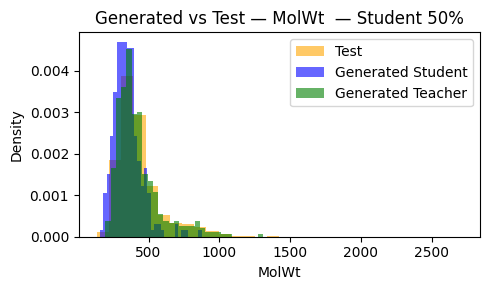

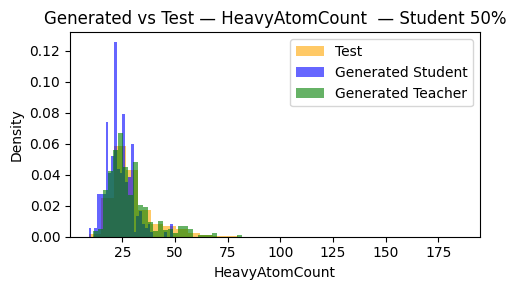

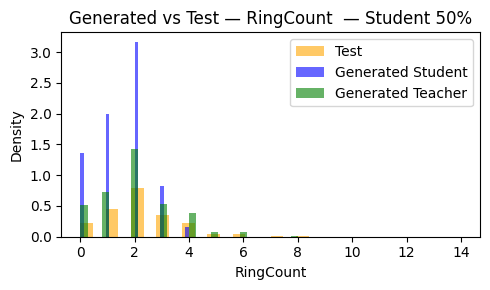

In [24]:
import matplotlib.pyplot as plt

PROPS_TO_PLOT = ["MolWt", "HeavyAtomCount", "RingCount"]

for p in PROPS_TO_PLOT:
    plt.figure(figsize=(5,3))

    # 🟠 Test distribution
    plt.hist(
        df[p],
        bins=30,
        density=True,
        alpha=0.6,
        label="Test",
        color="orange"
    )

    # 🔵 Generated Student distribution
    plt.hist(
        valid_df[p],
        bins=30,
        density=True,
        alpha=0.6,
        label="Generated Student",
        color="blue"
    )

    
    # 🔵 Generated Teacher distribution
    plt.hist(
        valid_df_Teacher[p],
        bins=30,
        density=True,
        alpha=0.6,
        label="Generated Teacher",
        color="green"
    )

    plt.xlabel(p)
    plt.ylabel("Density")
    plt.title(f"Generated vs Test — {p}  — Student {cap}%")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

p = "MolWt"

plt.figure(figsize=(5,3))

plt.hist(
    df_test_props[p],
    bins=30,
    density=True,
    alpha=0.5,
    label="Test (Real)",
    color="orange"
)

plt.hist(
    df_teacher_props[p],
    bins=30,
    density=True,
    alpha=0.5,
    label="Teacher",
    color="blue"
)

plt.hist(
    df_student_props[p],
    bins=30,
    density=True,
    alpha=0.5,
    label="Student",
    color="green"
)

plt.xlabel(p)
plt.ylabel("Density")
plt.title(f"Property distribution comparison — {p}")
plt.legend()
plt.tight_layout()
plt.show()


### Notes
- All generation uses the **official `generate_conditioned` function**
- Chemical validity is evaluated **exclusively via RDKit sanitization**
- Property computation uses `rdkit_properties_raw`
- Comparisons are **test vs generated**, never training vs generated
- This notebook directly verifies the results reported in **Chapter 4**


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
SEED=40

def get_property_column(df, prop_name):
    """
    Returns the appropriate column name for a property.
    If normalized version exists (prop_norm), use it.
    Otherwise, use the raw property.
    """
    norm_col = f"{prop_name}_norm"
    if norm_col in df.columns:
        return norm_col
    elif prop_name in df.columns:
        return prop_name
    else:
        raise ValueError(f"Property '{prop_name}' not found (raw or normalized)")


# ===============================
# Paths (AS PROVIDED BY YOU)
# ===============================

PATH_TRAIN = r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx\data\polymers_with_properties_normalized_train.csv"
PATH_TEST = r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx\data\polymers_with_properties_normalized_test.csv"
PATH_GENERATED = r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx\results\eval_teacher\valid_generated_molecules.csv"

# ===============================
# Properties
# ===============================

PROPERTY_BASE_COLS = [
    "MolWt", "HeavyAtomCount", "NHOHCount", "NOCount",
    "NumAliphaticCarbocycles", "NumAliphaticHeterocycles",
    "NumAliphaticRings", "NumAromaticCarbocycles",
    "NumAromaticHeterocycles", "NumAromaticRings",
    "NumHAcceptors", "NumHDonors", "NumHeteroatoms",
    "NumRotatableBonds", "RingCount"
]

# ===============================
# MMD (1D RBF)
# ===============================

def compute_mmd(x, y, gamma=None):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)

    if gamma is None:
        gamma = 1.0 / (np.std(np.vstack([x, y])) + 1e-8)

    k_xx = rbf_kernel(x, x, gamma=gamma)
    k_yy = rbf_kernel(y, y, gamma=gamma)
    k_xy = rbf_kernel(x, y, gamma=gamma)

    return k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()

# ===============================
# Load data
# ===============================

df_train = pd.read_csv(PATH_TRAIN)
df_test = pd.read_csv(PATH_TEST)
df_generated = pd.read_csv(PATH_GENERATED)

# ===============================
# Build table
# ===============================

rows = []

comparison = []

MAX_MMD_SAMPLES = len(df_generated)   # مثلاً 258 یا 500

rng = np.random.default_rng(SEED)

for p in PROPERTY_BASE_COLS:
    col_train = get_property_column(df_train, p)
    col_test  = get_property_column(df_test, p)
    col_gen   = p

    # --- Subsample train to match generated size ---
    train_vals = rng.choice(
        df_train[col_train].values,
        size=MAX_MMD_SAMPLES,
        replace=False
    )

    test_vals = rng.choice(
        df_test[col_test].values,
        size=MAX_MMD_SAMPLES,
        replace=False
    )

    gen_vals = df_generated[col_gen].values

    mmd_train = compute_mmd(train_vals, gen_vals)
    mmd_test  = compute_mmd(test_vals, gen_vals)

    comparison.append({
        "property": p,
        "MMD(train, generated)": mmd_train,
        "MMD(test, generated)": mmd_test,
        "gap(test - train)": mmd_test - mmd_train
    })

df_mmd_gap = pd.DataFrame(comparison)
print(df_mmd_gap)



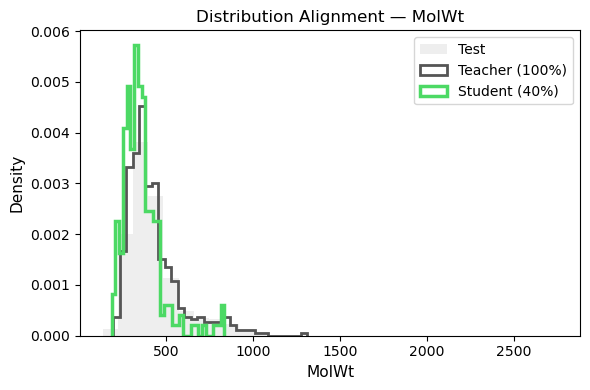

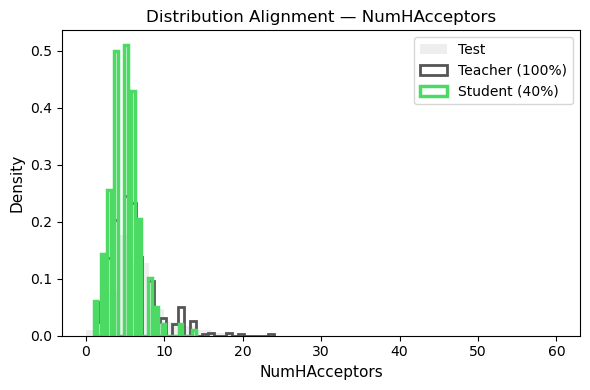

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# =============================
# Paths
# =============================

BASE_PATH = Path(r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx")

student_path = BASE_PATH / "results" / "eval_student_40" / "valid_generated_molecules.csv"
teacher_path = BASE_PATH / "results" / "eval_teacher" / "valid_generated_molecules.csv"
test_path    = BASE_PATH / "data" / "polymers_with_properties_normalized_train.csv"

# =============================
# Load data
# =============================

df_student = pd.read_csv(student_path)
df_teacher = pd.read_csv(teacher_path)
df_test    = pd.read_csv(test_path)

# =============================
# Template Colors (IU style)
# =============================

IU_GREEN   = "#4CD964"
DARK_GREY  = "#555555"
LIGHT_GREY = "#CFCFCF"

PROPS_TO_PLOT = ["MolWt", "NumHAcceptors"]

# =============================
# Plot
# =============================

for p in PROPS_TO_PLOT:

    plt.figure(figsize=(6,4))
    bins = 30

    # Test distribution (light grey fill)
    plt.hist(
        df_test[p],
        bins=bins,
        density=True,
        alpha=0.35,
        color=LIGHT_GREY,
        label="Test"
    )

    # Teacher distribution (dark grey line)
    plt.hist(
        df_teacher[p],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        color=DARK_GREY,
        label="Teacher (100%)"
    )

    # Student distribution (IU green highlight)
    plt.hist(
        df_student[p],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.5,
        color=IU_GREEN,
        label="Student (40%)"
    )

    plt.xlabel(p, fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.title(f"Distribution Alignment — {p}", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [15]:
import torch
from transformers import AutoModelForSeq2SeqLM

TEACHER_DIR = PROJECT_ROOT / "checkpoints" / "teacher" / "model"
STUDENT_DIR = PROJECT_ROOT / "checkpoints" / "polytao_student_distilled" / "student_40" / "model"

teacher = AutoModelForSeq2SeqLM.from_pretrained(
    TEACHER_DIR
).to(DEVICE).eval()

student = AutoModelForSeq2SeqLM.from_pretrained( STUDENT_DIR
).to(DEVICE).eval()

def count_params(model):
    return sum(p.numel() for p in model.parameters())

teacher_params = count_params(teacher)
student_params = count_params(student)

print("Teacher params:", teacher_params)
print("Student params:", student_params)
print("Reduction %:", 100 * (teacher_params - student_params) / teacher_params)


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Teacher params: 222905088
Student params: 173349120
Reduction %: 22.231869377517306


In [28]:
import pandas as pd
import numpy as np

def compute_rmse(df):
    rmses = {}
    for col in df.columns:
        if col.endswith("_target"):
            prop = col.replace("_target", "")
            pred = df[prop]
            true = df[col]
            rmse = np.sqrt(np.mean((true - pred) ** 2))
            rmses[prop] = rmse
    return rmses
TEACHER_DIR = PROJECT_ROOT / "result" / "eval_teacher" / "valid_generated_molecules.csv" 
STUDENT_DIR = PROJECT_ROOT / "result" / "eval_student_40" / "valid_generated_molecules.csv" 

teacher_df = pd.read_csv(r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx\results\eval_teacher\teacher_valid_samples.csv")

student_df = pd.read_csv(r"C:\uni\Mastertheses\Workspace\PolyTao\poly_fold_rx\results\eval_student_40\valid_generated_molecules.csv")

teacher_rmse = compute_rmse(teacher_df)
student_rmse = compute_rmse(student_df)

print("Teacher RMSE:", teacher_rmse)
print("Student 40% RMSE:", student_rmse)

print("\nMean RMSE:")
print("Teacher:", np.mean(list(teacher_rmse.values())))
print("Student 40%:", np.mean(list(student_rmse.values())))


Teacher RMSE: {'MolWt': 283.0818064622426, 'HeavyAtomCount': 18.873713314119346, 'NHOHCount': 2.7786561918593202, 'NOCount': 5.736460297447028, 'NumAliphaticCarbocycles': 0.6499850922559984, 'NumAliphaticHeterocycles': 0.6225728063646904, 'NumAliphaticRings': 1.0134751022821116, 'NumAromaticCarbocycles': 1.5700688771737905, 'NumAromaticHeterocycles': 0.7874992309581578, 'NumAromaticRings': 1.6210820388691578, 'NumHAcceptors': 4.7032068887897855, 'NumHDonors': 2.7194390666476242, 'NumHeteroatoms': 6.042164507689649, 'NumRotatableBonds': 12.29624635482734, 'RingCount': 1.7729666812191305}
Student 40% RMSE: {'MolWt': 372.67849348190344, 'HeavyAtomCount': 4.012701074277079, 'NHOHCount': 0.661855797999181, 'NOCount': 1.008810742926664, 'NumAliphaticCarbocycles': 0.325875267956141, 'NumAliphaticHeterocycles': 0.2822162605150792, 'NumAliphaticRings': 0.3120018152885698, 'NumAromaticCarbocycles': 0.41541108757641015, 'NumAromaticHeterocycles': 0.1629376339780705, 'NumAromaticRings': 1.56468880